In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..") / "src"))

import time
import pandas as pd
from prospect.geology import get_geology

DATA = Path("..") / "data"
RAW = DATA / "raw"
PROCESSED = DATA / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

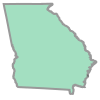

In [2]:
import geopandas as gpd

states = gpd.read_file(RAW / "cb_2023_us_state_500k.zip")
ga = states[states["STUSPS"] == "GA"].geometry.iloc[0]
ga   # renders the polygon inline — your visual sanity check

In [3]:
import numpy as np
from shapely.geometry import Point

rng = np.random.default_rng(42)   # same seed discipline as the positives

def sample_in_polygon(poly, n, rng):
    """Rejection sampling: throw darts at the bounding box, keep those inside."""
    minx, miny, maxx, maxy = poly.bounds
    pts = []
    while len(pts) < n:
        xs = rng.uniform(minx, maxx, n)
        ys = rng.uniform(miny, maxy, n)
        for x, y in zip(xs, ys):
            if poly.contains(Point(x, y)):
                pts.append((y, x))       # (lat, lng)
            if len(pts) == n:
                break
    return pts

In [4]:
from shapely.geometry import Point

pos = pd.read_csv(PROCESSED / "positives_gold.csv")
pos_pts = [Point(r.lng, r.lat) for r in pos.itertuples()]

# D7(b): size the buffer with evidence, not vibes.
test_pts = sample_in_polygon(ga, 1000, rng)
for radius in [0.005, 0.01, 0.02, 0.05]:      # ~0.5, 1.1, 2.2, 5.5 km
    n_close = sum(
        any(Point(lng, lat).distance(q) < radius for q in pos_pts)
        for lat, lng in test_pts
    )
    print(f"{radius}° (~{radius*111:.1f}km): {n_close}/1000 excluded")

0.005° (~0.6km): 3/1000 excluded
0.01° (~1.1km): 4/1000 excluded
0.02° (~2.2km): 24/1000 excluded
0.05° (~5.6km): 73/1000 excluded


In [5]:
def far_from_positives(lat, lng, radius_deg=0.01):
    p = Point(lng, lat)
    return all(p.distance(q) > radius_deg for q in pos_pts)

n_neg = len(pos)                          # 1:1 with positives (D7a)
raw_pts = sample_in_polygon(ga, n_neg * 2, rng)   # oversample; buffer + NO_COVERAGE will cull

rows = []
for i, (lat, lng) in enumerate(raw_pts):
    if len(rows) >= n_neg:
        break
    if not far_from_positives(lat, lng):   # D7b buffer
        continue
    geo = get_geology(lat, lng)
    rows.append({"lat": lat, "lng": lng, "label": 0, **geo})
    if len(rows) % 25 == 0:
        print(f"{len(rows)}/{n_neg}  [{geo['status']}]", flush=True)
    time.sleep(0.4)

neg_table = pd.DataFrame(rows)
neg_table.to_csv(PROCESSED / "pseudo_absences.csv", index=False)
print(f"\nfinal: {len(neg_table)} negatives")
neg_table["status"].value_counts()

25/509  [OK]
50/509  [OK]
75/509  [OK]
100/509  [OK]
125/509  [OK]
150/509  [OK]
175/509  [OK]
200/509  [OK]
225/509  [OK]
250/509  [OK]
275/509  [OK]
300/509  [OK]
325/509  [OK]
350/509  [OK]
375/509  [OK]
400/509  [OK]
425/509  [OK]
450/509  [OK]
475/509  [OK]
500/509  [OK]

final: 509 negatives


status
OK    509
Name: count, dtype: int64